Saving optional_external_data.csv to optional_external_data (1).csv
Saving student_test.csv to student_test.csv
Saving student_train.csv to student_train.csv
Device: cuda
GPU: Tesla T4
History: (43656, 12)
Future features: (168, 11)
Data checks passed.


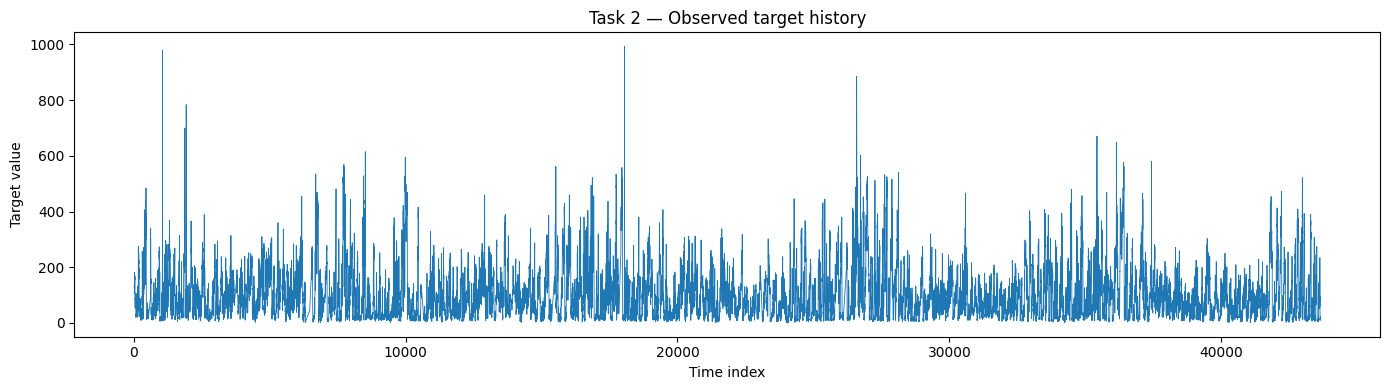

In [2]:
# Cell 1 — Upload, load, and validate the Task 2 data
from google.colab import files
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

uploaded = files.upload()

train_df = pd.read_csv("student_train.csv")
test_df = pd.read_csv("student_test.csv")
external_df = pd.read_csv("optional_external_data.csv")

assert np.array_equal(train_df["time_idx"], np.arange(1, 43657))
assert np.array_equal(test_df["time_idx"], np.arange(43657, 43825))
assert np.array_equal(external_df["time_idx"], np.arange(1, 43825))
assert train_df["value"].notna().all()
assert test_df["value"].isna().all()
assert external_df.notna().all().all()

# Align external features explicitly using the time index.
history = train_df.merge(
    external_df, on="time_idx", how="left", validate="one_to_one"
)
future = test_df[["time_idx"]].merge(
    external_df, on="time_idx", how="left", validate="one_to_one"
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRED_LEN = 168

print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("History:", history.shape)
print("Future features:", future.shape)
print("Data checks passed.")

plt.figure(figsize=(14, 4))
plt.plot(history["time_idx"], history["value"], linewidth=0.6)
plt.xlabel("Time index")
plt.ylabel("Target value")
plt.title("Task 2 — Observed target history")
plt.tight_layout()
plt.show()

In [4]:
import io
import re

def read_uploaded_csv(original_name):
    stem = original_name.removesuffix(".csv")
    pattern = re.compile(
        rf"{re.escape(stem)}(?: \(\d+\))?\.csv"
    )
    matches = [name for name in uploaded if pattern.fullmatch(name)]

    if len(matches) != 1:
        raise ValueError(
            f"Expected one upload for {original_name}; "
            f"found {matches}. Available: {list(uploaded)}"
        )

    actual_name = matches[0]
    print("Loading:", actual_name)
    return pd.read_csv(io.BytesIO(uploaded[actual_name]))

train_df = read_uploaded_csv("student_train.csv")
test_df = read_uploaded_csv("student_test.csv")
external_df = read_uploaded_csv("optional_external_data.csv")

Loading: student_train.csv
Loading: student_test.csv
Loading: optional_external_data (1).csv


In [5]:
history = train_df.merge(
    external_df, on="time_idx", validate="one_to_one"
)
future = test_df[["time_idx"]].merge(
    external_df, on="time_idx", validate="one_to_one"
)

assert np.array_equal(history["time_idx"], np.arange(1, 43657))
assert np.array_equal(future["time_idx"], np.arange(43657, 43825))
assert history.notna().all().all()
assert future.notna().all().all()

PRED_LEN = 168
SEQ_LEN = 336
LABEL_LEN = 168
VAL_BLOCKS = 20
TRAIN_END = len(history) - VAL_BLOCKS * PRED_LEN

feature_cols = [c for c in external_df.columns if c != "time_idx"]

y = history["value"].to_numpy(dtype=np.float32)
x = history[feature_cols].to_numpy(dtype=np.float32)
x_future = future[feature_cols].to_numpy(dtype=np.float32)

# Fit scalers using training rows only.
y_mean = float(y[:TRAIN_END].mean())
y_std = max(float(y[:TRAIN_END].std()), 1e-6)
x_mean = x[:TRAIN_END].mean(axis=0)
x_std = np.maximum(x[:TRAIN_END].std(axis=0), 1e-6)

y_scaled = ((y - y_mean) / y_std).astype(np.float32)
x_scaled = ((x - x_mean) / x_std).astype(np.float32)
x_future_scaled = ((x_future - x_mean) / x_std).astype(np.float32)

train_origins = np.arange(
    SEQ_LEN, TRAIN_END - PRED_LEN + 1, 24
)
val_origins = np.arange(TRAIN_END, len(y), PRED_LEN)

assert train_origins[-1] + PRED_LEN <= TRAIN_END
assert len(val_origins) == VAL_BLOCKS
assert val_origins[-1] + PRED_LEN == len(y)

print(f"Training indices:   1–{TRAIN_END}")
print(f"Validation indices: {TRAIN_END + 1}–{len(y)}")
print(f"Training windows:   {len(train_origins)}")
print(f"Validation blocks:  {len(val_origins)}")
print(f"Context / horizon:  {SEQ_LEN} / {PRED_LEN}")
print(f"Target scaler: mean={y_mean:.3f}, std={y_std:.3f}")

Training indices:   1–40296
Validation indices: 40297–43656
Training windows:   1659
Validation blocks:  20
Context / horizon:  336 / 168
Target scaler: mean=98.677, std=90.567


In [6]:
# Cell 3 — Window loaders and validation baselines
from torch.utils.data import Dataset, DataLoader

class ForecastDataset(Dataset):
    def __init__(self, origins):
        self.origins = np.asarray(origins)

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, index):
        t = int(self.origins[index])

        return {
            "past_y": torch.from_numpy(
                y_scaled[t - SEQ_LEN:t, None].copy()
            ),
            "past_x": torch.from_numpy(
                x_scaled[t - SEQ_LEN:t].copy()
            ),
            "future_x": torch.from_numpy(
                x_scaled[t:t + PRED_LEN].copy()
            ),
            "target": torch.from_numpy(
                y_scaled[t:t + PRED_LEN, None].copy()
            ),
        }

train_dataset = ForecastDataset(train_origins)
val_dataset = ForecastDataset(val_origins)

train_loader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    val_dataset, batch_size=32, shuffle=False, num_workers=0
)

batch = next(iter(train_loader))
for name, tensor in batch.items():
    print(f"{name:10s}: {tuple(tensor.shape)}")
    assert torch.isfinite(tensor).all()

def forecast_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=np.float64)
    predicted = np.asarray(predicted, dtype=np.float64)
    error = predicted - actual

    # A pair of zeros contributes zero to sMAPE.
    denominator = np.abs(actual) + np.abs(predicted)
    smape_terms = np.divide(
        2 * np.abs(error),
        denominator,
        out=np.zeros_like(error),
        where=denominator > 0,
    )
    return {
        "MAE": np.abs(error).mean(),
        "RMSE": np.sqrt(np.square(error).mean()),
        "sMAPE (%)": 100 * smape_terms.mean(),
    }

# All predictions use only target values preceding each origin.
val_actual = np.stack([
    y[t:t + PRED_LEN] for t in val_origins
])

baseline_predictions = {
    "Last value": np.stack([
        np.full(PRED_LEN, y[t - 1]) for t in val_origins
    ]),
    "Last 168 mean": np.stack([
        np.full(PRED_LEN, y[t - 168:t].mean())
        for t in val_origins
    ]),
    "Repeat last 168": np.stack([
        y[t - 168:t] for t in val_origins
    ]),
    "Training mean": np.full_like(val_actual, y_mean),
}

baseline_results = pd.DataFrame([
    {"Model": name, **forecast_metrics(val_actual, prediction)}
    for name, prediction in baseline_predictions.items()
]).sort_values("RMSE").reset_index(drop=True)

display(baseline_results.round(3))

past_y    : (32, 336, 1)
past_x    : (32, 336, 10)
future_x  : (32, 168, 10)
target    : (32, 168, 1)


,Model,MAE,RMSE,sMAPE (%)
0,Training mean,72.049,93.990,82.662
1,Last 168 mean,70.544,94.229,80.659
2,Repeat last 168,92.980,131.254,96.531
3,Last value,103.557,160.225,91.788


In [7]:
# Cell 4 — Reference Autoformer with optional external features
import subprocess
import sys
from pathlib import Path
from types import SimpleNamespace
import torch.nn as nn

REPO_DIR = Path("/content/Autoformer_reference")

if not (REPO_DIR / ".git").exists():
    subprocess.run(
        ["git", "clone", "https://github.com/thuml/Autoformer.git",
         str(REPO_DIR)],
        check=True,
    )

REFERENCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"],
    text=True,
).strip()
print("Autoformer reference commit:", REFERENCE_COMMIT)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from models.Autoformer import Model as ReferenceAutoformer


class TargetFeatureEmbedding(nn.Module):
    """Embed target values and, optionally, aligned external features."""
    def __init__(self, d_model, use_external, dropout):
        super().__init__()
        self.value_embedding = nn.Conv1d(
            1, d_model, kernel_size=3, padding=1,
            padding_mode="circular", bias=False,
        )
        self.external_embedding = (
            nn.Linear(len(feature_cols), d_model, bias=False)
            if use_external else None
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, values, features):
        embedded = self.value_embedding(
            values.transpose(1, 2)
        ).transpose(1, 2)

        if self.external_embedding is not None:
            embedded = embedded + self.external_embedding(features)

        return self.dropout(embedded)


class Task2Autoformer(nn.Module):
    def __init__(self, use_external=False):
        super().__init__()

        config = SimpleNamespace(
            seq_len=SEQ_LEN,
            label_len=LABEL_LEN,
            pred_len=PRED_LEN,
            enc_in=1,
            dec_in=1,
            c_out=1,
            d_model=32,
            n_heads=4,
            d_ff=64,
            e_layers=1,
            d_layers=1,
            moving_avg=25,
            factor=2,
            dropout=0.1,
            activation="gelu",
            embed="timeF",
            freq="h",
            output_attention=False,
        )

        self.core = ReferenceAutoformer(config)

        # Replace calendar embeddings with supplied external features.
        # Target remains univariate, including the trend stream.
        self.core.enc_embedding = TargetFeatureEmbedding(
            config.d_model, use_external, config.dropout
        )
        self.core.dec_embedding = TargetFeatureEmbedding(
            config.d_model, use_external, config.dropout
        )

    def forward(self, past_y, past_x, future_x):
        batch_size = past_y.shape[0]

        # Decoder contains observed targets followed by zeros.
        # No future target labels enter this forward pass.
        decoder_values = torch.cat([
            past_y[:, -LABEL_LEN:],
            past_y.new_zeros(batch_size, PRED_LEN, 1),
        ], dim=1)

        decoder_features = torch.cat([
            past_x[:, -LABEL_LEN:],
            future_x,
        ], dim=1)

        return self.core(
            past_y, past_x,
            decoder_values, decoder_features,
        )


# Check both configurations before training.
check_batch = next(iter(train_loader))
inputs = [
    check_batch[name].to(DEVICE)
    for name in ("past_y", "past_x", "future_x")
]

for use_external in (False, True):
    model = Task2Autoformer(use_external).to(DEVICE)
    model.eval()

    with torch.no_grad():
        prediction = model(*inputs)

    assert prediction.shape == (
        inputs[0].shape[0], PRED_LEN, 1
    )
    assert torch.isfinite(prediction).all()

    # Check that gradients reach model parameters.
    model.train()
    loss = (model(*inputs) - check_batch["target"].to(DEVICE)).square().mean()
    loss.backward()

    gradients = [
        p.grad for p in model.parameters() if p.grad is not None
    ]
    assert gradients
    assert all(torch.isfinite(g).all() for g in gradients)
    assert any(g.abs().sum().item() > 0 for g in gradients)

    parameter_count = sum(
        p.numel() for p in model.parameters() if p.requires_grad
    )
    print(
        f"External={use_external} | "
        f"output={tuple(prediction.shape)} | "
        f"parameters={parameter_count:,} | "
        "forward/backward checks passed"
    )

    del model

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

Autoformer reference commit: 51c7d416ae120b805fd5beef2f4ccf7de496a6ff
External=False | output=(32, 168, 1) | parameters=21,313 | forward/backward checks passed
External=True | output=(32, 168, 1) | parameters=21,953 | forward/backward checks passed


In [8]:
# Cell 5 — Train the first Autoformer pilot
import random
import time
import copy
from pathlib import Path

SEED = 0
MAX_EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 1e-3
USE_EXTERNAL = False

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Seed the shuffle order explicitly.
generator = torch.Generator().manual_seed(SEED)
pilot_train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=generator,
)

model = Task2Autoformer(USE_EXTERNAL).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4
)

OUTPUT_DIR = Path("/content/task2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
run_name = f"external{int(USE_EXTERNAL)}_seed{SEED}"
checkpoint_path = OUTPUT_DIR / f"{run_name}_best.pt"

best_rmse = float("inf")
best_state = None
best_epoch = None
stale_epochs = 0
training_records = []

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
run_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.perf_counter()
    model.train()
    loss_sum = 0.0
    sample_count = 0

    for batch in pilot_train_loader:
        past_y = batch["past_y"].to(DEVICE)
        past_x = batch["past_x"].to(DEVICE)
        future_x = batch["future_x"].to(DEVICE)
        target = batch["target"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        prediction = model(past_y, past_x, future_x)
        loss = (prediction - target).square().mean()

        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0,
            error_if_nonfinite=True,
        )
        optimizer.step()

        loss_sum += loss.item() * target.shape[0]
        sample_count += target.shape[0]

    model.eval()
    validation_predictions = []

    with torch.no_grad():
        for batch in val_loader:
            prediction = model(
                batch["past_y"].to(DEVICE),
                batch["past_x"].to(DEVICE),
                batch["future_x"].to(DEVICE),
            )
            validation_predictions.append(
                prediction.cpu().numpy()[..., 0]
            )

    # Convert back to original units; enforce the known non-negative domain.
    val_prediction = np.maximum(
        np.concatenate(validation_predictions) * y_std + y_mean,
        0.0,
    )
    assert np.isfinite(val_prediction).all()
    metrics = forecast_metrics(val_actual, val_prediction)

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    epoch_seconds = time.perf_counter() - epoch_start

    training_records.append({
        "epoch": epoch,
        "train_scaled_MSE": loss_sum / sample_count,
        **metrics,
        "epoch_seconds": epoch_seconds,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train MSE={loss_sum / sample_count:.4f} | "
        f"val RMSE={metrics['RMSE']:.3f} | "
        f"MAE={metrics['MAE']:.3f} | "
        f"sMAPE={metrics['sMAPE (%)']:.2f}% | "
        f"{epoch_seconds:.1f}s"
    )

    if metrics["RMSE"] < best_rmse:
        best_rmse = metrics["RMSE"]
        best_epoch = epoch
        best_state = {
            name: tensor.detach().cpu().clone()
            for name, tensor in model.state_dict().items()
        }
        best_val_prediction = val_prediction.copy()
        stale_epochs = 0
    else:
        stale_epochs += 1

    if stale_epochs >= PATIENCE:
        print("Early stopping.")
        break

elapsed_seconds = time.perf_counter() - run_start
epochs_executed = len(training_records)
model.load_state_dict(best_state)

torch.save({
    "model_state_dict": best_state,
    "use_external": USE_EXTERNAL,
    "seed": SEED,
    "best_epoch": best_epoch,
    "epochs_executed": epochs_executed,
    "best_validation_RMSE": best_rmse,
    "reference_commit": REFERENCE_COMMIT,
    "seq_len": SEQ_LEN,
    "label_len": LABEL_LEN,
    "pred_len": PRED_LEN,
    "train_end": TRAIN_END,
    "feature_cols": feature_cols,
    "y_mean": y_mean,
    "y_std": y_std,
    "x_mean": x_mean,
    "x_std": x_std,
    "elapsed_seconds": elapsed_seconds,
}, checkpoint_path)

training_log = pd.DataFrame(training_records)
training_log.to_csv(
    OUTPUT_DIR / f"{run_name}_training_log.csv", index=False
)
np.save(
    OUTPUT_DIR / f"{run_name}_validation_predictions.npy",
    best_val_prediction,
)

print(f"\nBest epoch: {best_epoch}")
print(f"Epochs actually executed: {epochs_executed}")
print(f"Best validation RMSE: {best_rmse:.3f}")
print(f"Total run time: {elapsed_seconds / 60:.2f} minutes")
print("Checkpoint:", checkpoint_path)

display(training_log.round(3))

Epoch 01 | train MSE=1.1137 | val RMSE=94.915 | MAE=70.766 | sMAPE=81.36% | 1.7s
Epoch 02 | train MSE=1.0854 | val RMSE=94.501 | MAE=71.613 | sMAPE=81.38% | 1.6s
Epoch 03 | train MSE=1.0791 | val RMSE=94.158 | MAE=71.290 | sMAPE=81.10% | 1.6s
Epoch 04 | train MSE=1.0748 | val RMSE=93.675 | MAE=70.238 | sMAPE=80.68% | 2.0s
Epoch 05 | train MSE=1.0735 | val RMSE=93.667 | MAE=70.239 | sMAPE=80.40% | 1.9s
Epoch 06 | train MSE=1.0715 | val RMSE=95.091 | MAE=72.473 | sMAPE=81.91% | 1.6s
Epoch 07 | train MSE=1.0702 | val RMSE=95.000 | MAE=71.815 | sMAPE=81.51% | 1.6s
Epoch 08 | train MSE=1.0672 | val RMSE=94.110 | MAE=70.131 | sMAPE=81.11% | 1.5s
Early stopping.

Best epoch: 5
Epochs actually executed: 8
Best validation RMSE: 93.667
Total run time: 0.23 minutes
Checkpoint: /content/task2_outputs/external0_seed0_best.pt


,epoch,train_scaled_MSE,MAE,RMSE,sMAPE (%),epoch_seconds
0,1,1.114,70.766,94.915,81.357,1.730
1,2,1.085,71.613,94.501,81.379,1.575
2,3,1.079,71.290,94.158,81.104,1.644
3,4,1.075,70.238,93.675,80.678,1.983
4,5,1.073,70.239,93.667,80.400,1.885
5,6,1.072,72.473,95.091,81.913,1.571
6,7,1.070,71.815,95.000,81.509,1.597
7,8,1.067,70.131,94.110,81.110,1.526


In [9]:
# Cell 6 — Required external-feature ablation across three seeds
def train_experiment(use_external, seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(seed),
    )

    net = Task2Autoformer(use_external).to(DEVICE)
    opt = torch.optim.AdamW(
        net.parameters(), lr=1e-3, weight_decay=1e-4
    )
    parameter_count = sum(
        p.numel() for p in net.parameters() if p.requires_grad
    )

    name = f"external{int(use_external)}_seed{seed}"
    best_rmse = float("inf")
    best_state = None
    stale = 0
    records = []

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    started = time.perf_counter()

    for epoch in range(1, 11):
        epoch_started = time.perf_counter()
        net.train()
        loss_sum, count = 0.0, 0

        for batch in loader:
            target = batch["target"].to(DEVICE)
            opt.zero_grad(set_to_none=True)

            prediction = net(
                batch["past_y"].to(DEVICE),
                batch["past_x"].to(DEVICE),
                batch["future_x"].to(DEVICE),
            )
            loss = (prediction - target).square().mean()
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss: {name}")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                net.parameters(), 1.0, error_if_nonfinite=True
            )
            opt.step()

            loss_sum += loss.item() * target.shape[0]
            count += target.shape[0]

        net.eval()
        predictions = []
        with torch.no_grad():
            for batch in val_loader:
                prediction = net(
                    batch["past_y"].to(DEVICE),
                    batch["past_x"].to(DEVICE),
                    batch["future_x"].to(DEVICE),
                )
                predictions.append(prediction.cpu().numpy()[..., 0])

        prediction = np.maximum(
            np.concatenate(predictions) * y_std + y_mean, 0.0
        )
        assert np.isfinite(prediction).all()
        metrics = forecast_metrics(val_actual, prediction)

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        records.append({
            "epoch": epoch,
            "train_scaled_MSE": loss_sum / count,
            **metrics,
            "epoch_seconds": time.perf_counter() - epoch_started,
        })

        if metrics["RMSE"] < best_rmse:
            best_rmse = metrics["RMSE"]
            best_epoch = epoch
            best_metrics = metrics.copy()
            best_prediction = prediction.copy()
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in net.state_dict().items()
            }
            stale = 0
        else:
            stale += 1

        if stale >= 3:
            break

    elapsed = time.perf_counter() - started

    torch.save({
        "model_state_dict": best_state,
        "use_external": use_external,
        "seed": seed,
        "best_epoch": best_epoch,
        "epochs_executed": len(records),
        "best_validation_RMSE": best_rmse,
        "reference_commit": REFERENCE_COMMIT,
        "seq_len": SEQ_LEN,
        "label_len": LABEL_LEN,
        "pred_len": PRED_LEN,
        "train_end": TRAIN_END,
        "feature_cols": feature_cols,
        "y_mean": y_mean,
        "y_std": y_std,
        "x_mean": x_mean,
        "x_std": x_std,
        "elapsed_seconds": elapsed,
    }, OUTPUT_DIR / f"{name}_best.pt")

    pd.DataFrame(records).to_csv(
        OUTPUT_DIR / f"{name}_training_log.csv", index=False
    )
    np.save(
        OUTPUT_DIR / f"{name}_validation_predictions.npy",
        best_prediction,
    )

    result = {
        "External": use_external,
        "Seed": seed,
        **best_metrics,
        "Parameters": parameter_count,
        "Best epoch": best_epoch,
        "Epochs executed": len(records),
        "Seconds": elapsed,
    }
    print(
        f"{name} | RMSE={best_rmse:.3f} | "
        f"best epoch={best_epoch} | "
        f"executed={len(records)} | {elapsed:.1f}s"
    )

    del net, opt
    return result


# Reuse the saved pilot rather than train it again.
pilot_prediction = np.load(
    OUTPUT_DIR / "external0_seed0_validation_predictions.npy"
)
pilot_log = pd.read_csv(
    OUTPUT_DIR / "external0_seed0_training_log.csv"
)
pilot_best = pilot_log.loc[pilot_log["RMSE"].idxmin()]

ablation_rows = [{
    "External": False,
    "Seed": 0,
    **forecast_metrics(val_actual, pilot_prediction),
    "Parameters": 21313,
    "Best epoch": int(pilot_best["epoch"]),
    "Epochs executed": len(pilot_log),
    "Seconds": elapsed_seconds,
}]

for use_external, seed in [
    (False, 1), (False, 2),
    (True, 0), (True, 1), (True, 2),
]:
    ablation_rows.append(train_experiment(use_external, seed))
    # Save progress after every completed run.
    pd.DataFrame(ablation_rows).to_csv(
        OUTPUT_DIR / "ablation_per_seed.csv", index=False
    )

ablation_results = pd.DataFrame(ablation_rows)
summary = ablation_results.groupby("External").agg(
    RMSE_mean=("RMSE", "mean"),
    RMSE_std=("RMSE", "std"),
    MAE_mean=("MAE", "mean"),
    sMAPE_mean=("sMAPE (%)", "mean"),
    Parameters=("Parameters", "first"),
    Seconds_mean=("Seconds", "mean"),
)
summary.to_csv(OUTPUT_DIR / "ablation_summary.csv")

print("\nPer-seed results:")
display(ablation_results.round(3))
print("\nSummary across seeds:")
display(summary.round(3))

paired = ablation_results.pivot(
    index="Seed", columns="External", values="RMSE"
)
paired["RMSE improvement with external"] = paired[False] - paired[True]
print("\nPositive improvement means external features helped:")
display(paired.round(3))

external0_seed1 | RMSE=92.773 | best epoch=7 | executed=10 | 16.5s
external0_seed2 | RMSE=93.643 | best epoch=5 | executed=8 | 13.3s
external1_seed0 | RMSE=72.134 | best epoch=10 | executed=10 | 16.4s
external1_seed1 | RMSE=67.747 | best epoch=3 | executed=6 | 10.4s
external1_seed2 | RMSE=73.087 | best epoch=7 | executed=10 | 16.4s

Per-seed results:


,External,Seed,MAE,RMSE,sMAPE (%),Parameters,Best epoch,Epochs executed,Seconds
0,False,0,70.239,93.667,80.400,21313,5,8,13.521
1,False,1,69.578,92.773,80.064,21313,7,10,16.530
2,False,2,71.167,93.643,80.863,21313,5,8,13.259
3,True,0,51.423,72.134,72.978,21953,10,10,16.364
4,True,1,47.446,67.747,65.780,21953,3,6,10.395
5,True,2,53.874,73.087,69.784,21953,7,10,16.431



Summary across seeds:


,RMSE_mean,RMSE_std,MAE_mean,sMAPE_mean,Parameters,Seconds_mean
External,,,,,,
False,93.361,0.509,70.328,80.443,21313,14.437
True,70.989,2.848,50.914,69.514,21953,14.397



Positive improvement means external features helped:


External,False,True,RMSE improvement with external
Seed,,,
0,93.667,72.134,21.533
1,92.773,67.747,25.026
2,93.643,73.087,20.556


,External,Without external,With external,Improvement
Block,Start index,,,
1,40297,55.617,59.379,-3.761
2,40465,32.181,37.359,-5.178
3,40633,53.300,36.956,16.344
4,40801,53.708,41.582,12.126
5,40969,48.771,47.899,0.872
6,41137,38.907,39.940,-1.032
7,41305,45.557,47.660,-2.102
8,41473,46.418,45.859,0.559
9,41641,102.600,89.782,12.819


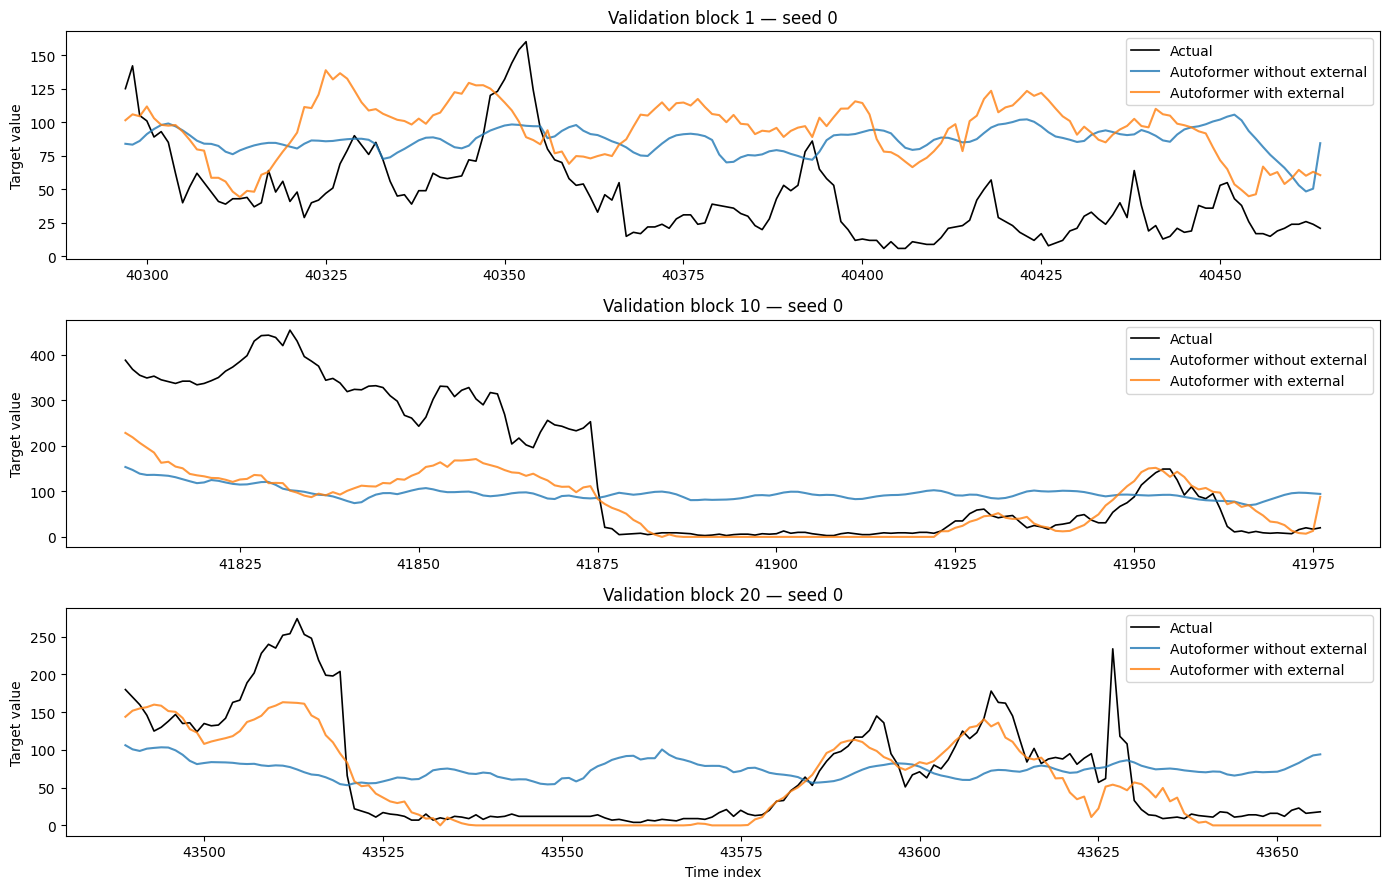

Blocks improved by external features: 16 out of 20


In [10]:
# Cell 7 — Inspect validation errors and forecasts
block_rows = []

for use_external in (False, True):
    for seed in (0, 1, 2):
        predictions = np.load(
            OUTPUT_DIR /
            f"external{int(use_external)}_seed{seed}_validation_predictions.npy"
        )

        for block, origin in enumerate(val_origins):
            block_rows.append({
                "External": use_external,
                "Seed": seed,
                "Block": block + 1,
                "Start index": int(origin + 1),
                **forecast_metrics(
                    val_actual[block], predictions[block]
                ),
            })

block_results = pd.DataFrame(block_rows)
block_results.to_csv(
    OUTPUT_DIR / "validation_block_metrics.csv", index=False
)

block_summary = block_results.groupby(
    ["Block", "Start index", "External"], as_index=False
)["RMSE"].mean()

comparison = block_summary.pivot(
    index=["Block", "Start index"],
    columns="External",
    values="RMSE",
).rename(columns={
    False: "Without external",
    True: "With external",
})

comparison["Improvement"] = (
    comparison["Without external"] - comparison["With external"]
)
display(comparison.round(3))

# Use a fixed seed for inspection, avoiding selection of the best seed.
inspection_seed = 0
pred_without = np.load(
    OUTPUT_DIR /
    f"external0_seed{inspection_seed}_validation_predictions.npy"
)
pred_with = np.load(
    OUTPUT_DIR /
    f"external1_seed{inspection_seed}_validation_predictions.npy"
)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# Fixed early, middle, and late blocks.
for ax, block in zip(axes, [0, 9, 19]):
    origin = val_origins[block]
    indices = np.arange(origin + 1, origin + PRED_LEN + 1)

    ax.plot(indices, val_actual[block],
            color="black", label="Actual", linewidth=1.2)
    ax.plot(indices, pred_without[block],
            label="Autoformer without external", alpha=0.8)
    ax.plot(indices, pred_with[block],
            label="Autoformer with external", alpha=0.8)
    ax.set_title(f"Validation block {block + 1} — seed 0")
    ax.set_ylabel("Target value")
    ax.legend()

axes[-1].set_xlabel("Time index")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "validation_forecasts.pdf",
    bbox_inches="tight",
)
plt.show()

print(
    "Blocks improved by external features:",
    int((comparison["Improvement"] > 0).sum()),
    "out of", len(comparison),
)

In [11]:
# Cell 8 — Historical-only external-feature ablation
class HistoricalOnlyDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        sample = dict(self.base_dataset[index])
        # Zero is the training mean after standardization.
        # No measured future external features enter the model.
        sample["future_x"] = torch.zeros_like(sample["future_x"])
        return sample


# Keep the previous experiments and their outputs intact.
original_train_dataset = train_dataset
original_val_loader = val_loader
original_output_dir = OUTPUT_DIR

historical_rows = []

try:
    train_dataset = HistoricalOnlyDataset(original_train_dataset)
    val_loader = DataLoader(
        HistoricalOnlyDataset(val_dataset),
        batch_size=32,
        shuffle=False,
        num_workers=0,
    )
    OUTPUT_DIR = original_output_dir / "historical_only"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    for seed in (0, 1, 2):
        result = train_experiment(use_external=True, seed=seed)
        result["Feature mode"] = "Historical only"
        historical_rows.append(result)

        pd.DataFrame(historical_rows).to_csv(
            OUTPUT_DIR / "historical_only_per_seed.csv",
            index=False,
        )

finally:
    train_dataset = original_train_dataset
    val_loader = original_val_loader
    OUTPUT_DIR = original_output_dir


# Compare with the experiments already completed.
existing_results = ablation_results.copy()
existing_results["Feature mode"] = existing_results["External"].map({
    False: "No external",
    True: "Historical + future",
})

feature_mode_results = pd.concat(
    [existing_results, pd.DataFrame(historical_rows)],
    ignore_index=True,
)

feature_mode_summary = feature_mode_results.groupby(
    "Feature mode"
).agg(
    RMSE_mean=("RMSE", "mean"),
    RMSE_std=("RMSE", "std"),
    MAE_mean=("MAE", "mean"),
    sMAPE_mean=("sMAPE (%)", "mean"),
    Parameters=("Parameters", "first"),
)

feature_mode_results.to_csv(
    OUTPUT_DIR / "feature_modes_per_seed.csv", index=False
)
feature_mode_summary.to_csv(
    OUTPUT_DIR / "feature_modes_summary.csv"
)

display(feature_mode_summary.round(3))

paired_modes = feature_mode_results.pivot(
    index="Seed", columns="Feature mode", values="RMSE"
)
paired_modes["Gain from future features"] = (
    paired_modes["Historical only"]
    - paired_modes["Historical + future"]
)
print("Positive gain means measured future features helped:")
display(paired_modes.round(3))

external1_seed0 | RMSE=92.155 | best epoch=10 | executed=10 | 16.1s
external1_seed1 | RMSE=94.120 | best epoch=4 | executed=7 | 11.3s
external1_seed2 | RMSE=93.815 | best epoch=4 | executed=7 | 11.5s


,RMSE_mean,RMSE_std,MAE_mean,sMAPE_mean,Parameters
Feature mode,,,,,
Historical + future,70.989,2.848,50.914,69.514,21953
Historical only,93.364,1.057,70.497,80.497,21953
No external,93.361,0.509,70.328,80.443,21313


Positive gain means measured future features helped:


Feature mode,Historical + future,Historical only,No external,Gain from future features
Seed,,,,
0,72.134,92.155,93.667,20.022
1,67.747,94.120,92.773,26.373
2,73.087,93.815,93.643,20.729


In [12]:
# Cell 9 — Final refit on all observed data and forecast generation
import json

FINAL_SEED = 0
FINAL_EPOCHS = 7

random.seed(FINAL_SEED)
np.random.seed(FINAL_SEED)
torch.manual_seed(FINAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(FINAL_SEED)

# Refit scalers using all observed history.
# Hidden test targets remain unavailable and are never used.
final_y_mean = float(y.mean())
final_y_std = max(float(y.std()), 1e-6)
final_x_mean = x.mean(axis=0)
final_x_std = np.maximum(x.std(axis=0), 1e-6)

final_y_scaled = (
    (y - final_y_mean) / final_y_std
).astype(np.float32)
final_x_scaled = (
    (x - final_x_mean) / final_x_std
).astype(np.float32)
final_future_scaled = (
    (x_future - final_x_mean) / final_x_std
).astype(np.float32)


class FinalTrainingDataset(Dataset):
    def __init__(self):
        self.origins = np.arange(
            SEQ_LEN, len(y) - PRED_LEN + 1, 24
        )

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, index):
        t = int(self.origins[index])
        return {
            "past_y": torch.from_numpy(
                final_y_scaled[t - SEQ_LEN:t, None].copy()
            ),
            "past_x": torch.from_numpy(
                final_x_scaled[t - SEQ_LEN:t].copy()
            ),
            "future_x": torch.from_numpy(
                final_x_scaled[t:t + PRED_LEN].copy()
            ),
            "target": torch.from_numpy(
                final_y_scaled[t:t + PRED_LEN, None].copy()
            ),
        }


final_loader = DataLoader(
    FinalTrainingDataset(),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(FINAL_SEED),
)

final_model = Task2Autoformer(use_external=True).to(DEVICE)
final_optimizer = torch.optim.AdamW(
    final_model.parameters(), lr=1e-3, weight_decay=1e-4
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
final_started = time.perf_counter()
final_records = []

for epoch in range(1, FINAL_EPOCHS + 1):
    final_model.train()
    loss_sum, count = 0.0, 0

    for batch in final_loader:
        target = batch["target"].to(DEVICE)
        final_optimizer.zero_grad(set_to_none=True)

        prediction = final_model(
            batch["past_y"].to(DEVICE),
            batch["past_x"].to(DEVICE),
            batch["future_x"].to(DEVICE),
        )
        loss = (prediction - target).square().mean()
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite final training loss.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            final_model.parameters(), 1.0,
            error_if_nonfinite=True,
        )
        final_optimizer.step()

        loss_sum += loss.item() * target.shape[0]
        count += target.shape[0]

    final_records.append({
        "epoch": epoch,
        "train_scaled_MSE": loss_sum / count,
    })
    print(
        f"Final epoch {epoch}/{FINAL_EPOCHS} | "
        f"train MSE={loss_sum / count:.4f}"
    )

if DEVICE.type == "cuda":
    torch.cuda.synchronize()
final_seconds = time.perf_counter() - final_started

# One forecast from the end of the observed series.
final_model.eval()
with torch.no_grad():
    normalized_forecast = final_model(
        torch.from_numpy(
            final_y_scaled[-SEQ_LEN:, None].copy()
        ).unsqueeze(0).to(DEVICE),
        torch.from_numpy(
            final_x_scaled[-SEQ_LEN:].copy()
        ).unsqueeze(0).to(DEVICE),
        torch.from_numpy(
            final_future_scaled.copy()
        ).unsqueeze(0).to(DEVICE),
    ).cpu().numpy()[0, :, 0]

forecast = np.maximum(
    normalized_forecast * final_y_std + final_y_mean, 0.0
)
assert forecast.shape == (168,)
assert np.isfinite(forecast).all()

final_parameters = sum(
    p.numel() for p in final_model.parameters() if p.requires_grad
)

prediction_text = ",".join(f"{value:.8f}" for value in forecast)
assert len(prediction_text.split(",")) == 168

(OUTPUT_DIR / "leaderboard_predictions.txt").write_text(
    prediction_text
)
pd.DataFrame({
    "time_idx": test_df["time_idx"].to_numpy(),
    "prediction": forecast,
}).to_csv(OUTPUT_DIR / "final_forecast.csv", index=False)

pd.DataFrame(final_records).to_csv(
    OUTPUT_DIR / "final_training_log.csv", index=False
)

torch.save({
    "model_state_dict": {
        key: value.detach().cpu()
        for key, value in final_model.state_dict().items()
    },
    "reference_commit": REFERENCE_COMMIT,
    "feature_mode": "Historical + future",
    "feature_cols": feature_cols,
    "seed": FINAL_SEED,
    "final_refit_epochs": FINAL_EPOCHS,
    "parameters": final_parameters,
    "seq_len": SEQ_LEN,
    "label_len": LABEL_LEN,
    "pred_len": PRED_LEN,
    "y_mean": final_y_mean,
    "y_std": final_y_std,
    "x_mean": final_x_mean,
    "x_std": final_x_std,
    "final_fit_seconds": final_seconds,
}, OUTPUT_DIR / "final_autoformer.pt")

print(f"\nParameters: {final_parameters:,}")
print(f"Final refit epochs: {FINAL_EPOCHS}")
print(f"Final training time: {final_seconds:.2f}s")
print("Forecast indices: 43657–43824")
print("Prediction count:", len(forecast))
print("\n168 comma-separated predictions:")
print(prediction_text)

Final epoch 1/7 | train MSE=1.0214
Final epoch 2/7 | train MSE=0.7429
Final epoch 3/7 | train MSE=0.6886
Final epoch 4/7 | train MSE=0.6690
Final epoch 5/7 | train MSE=0.6480
Final epoch 6/7 | train MSE=0.6280
Final epoch 7/7 | train MSE=0.6270

Parameters: 21,953
Final refit epochs: 7
Final training time: 13.39s
Forecast indices: 43657–43824
Prediction count: 168

168 comma-separated predictions:
0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,4.12772369,10.52640533,12.65875244,19.25212097,20.18395233,23.59761810,21.63977051,24.85249329,25.46125031,31.32365417,35.45703888,40.57185745,56.38988113,66.18803406,74.72637939,81.18809509,88.84895325,95.35960388,108.74491119,114.97537231,122.34294891,127.72041321,125.50658417,131.40852356,134.90965271,133.42163086,135.13375854,136.24493408,140.59822083,138.31686401,137.18409729,136.17895508,135.98928833,137.55078125,138.07670593,139.80778503,152.63548279,157.15863037,155.73034668,153.25570679,153.56867981,153.18945312,150.84172058,137.

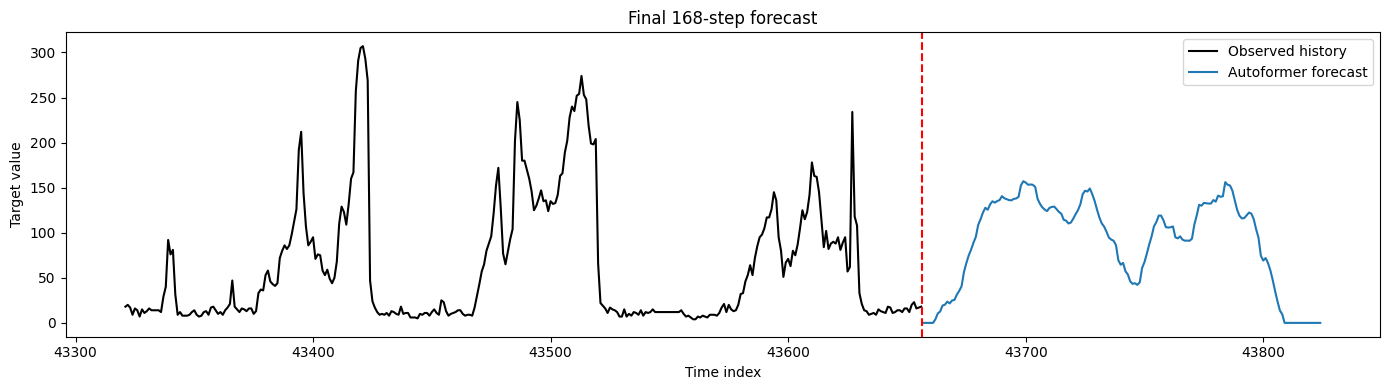

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Cell 10 — Final plot, metadata, and backup download
import shutil
import platform
from google.colab import files

plt.figure(figsize=(14, 4))
plt.plot(
    history["time_idx"].iloc[-336:],
    y[-336:],
    label="Observed history",
    color="black",
)
plt.plot(
    test_df["time_idx"],
    forecast,
    label="Autoformer forecast",
    color="tab:blue",
)
plt.axvline(43656.5, color="red", linestyle="--")
plt.xlabel("Time index")
plt.ylabel("Target value")
plt.title("Final 168-step forecast")
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "final_forecast.pdf", bbox_inches="tight"
)
plt.show()

metadata = {
    "name": "Namra Nadeem",
    "roll_number": "25280097",
    "reference_repository": "https://github.com/thuml/Autoformer",
    "reference_commit": REFERENCE_COMMIT,
    "feature_mode": "Historical + future",
    "parameters": final_parameters,
    "seed": FINAL_SEED,
    "selected_configuration_validation_epochs": 10,
    "final_refit_epochs": FINAL_EPOCHS,
    "declared_leaderboard_epochs": 10 + FINAL_EPOCHS,
    "epoch_selection": "Median best epoch across seeds 0, 1, 2",
    "validation_RMSE_mean": 70.989,
    "validation_RMSE_seed_std": 2.848,
    "forecast_start": 43657,
    "forecast_end": 43824,
    "forecast_count": len(forecast),
    "nonnegative_clipping": True,
    "final_fit_seconds": final_seconds,
    "python_version": platform.python_version(),
    "torch_version": str(torch.__version__),
}

(OUTPUT_DIR / "submission_metadata.json").write_text(
    json.dumps(metadata, indent=2)
)

# Preserve reference code used by the notebook.
source_dir = OUTPUT_DIR / "reference_source"
source_dir.mkdir(exist_ok=True)

for folder in ("models", "layers", "utils"):
    shutil.copytree(
        REPO_DIR / folder,
        source_dir / folder,
        dirs_exist_ok=True,
        ignore=shutil.ignore_patterns("__pycache__", "*.pyc"),
    )

for filename in ("LICENSE", "README.md"):
    source = REPO_DIR / filename
    if source.exists():
        shutil.copy2(source, source_dir / filename)

(source_dir / "COMMIT.txt").write_text(REFERENCE_COMMIT + "\n")

archive = shutil.make_archive(
    "/content/25280097_Task2_results",
    "zip",
    root_dir=OUTPUT_DIR,
)
files.download(archive)